# Stokes Formula – Flow Field and Pressure

Program calculates the flow profile for Stokes friction

In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt

sys.path.append('IncludeFolder')
sys.path.append('Data')

from PlotCircle import PlotCircle

## Parameters and Grid Definition

In [2]:
r0 = 1  # radius of sphere
v0 = 1  # velocity at infinity

z  = np.linspace(-4,4,81)
y  = np.linspace(-4,4,81)

z,y = np.meshgrid(z,y)

## Velocity Field Calculation

In [3]:
theta = np.arctan2(y,z)   # angle between z-direction velocity and position vector

r = np.sqrt(z**2 + y**2)  # distance from the center of the sphere

r[r < 0.99*r0] = np.nan   # Sphere exclusion region

A = v0*(1-(0.25*r0/r)*(3+1/r**2))
B = -3*v0*r0*(1-r0**2/r**2)/(4*r)

vz = A + B*np.cos(theta)*np.cos(theta) # z-component of velocity
vy = B*np.cos(theta)*np.sin(theta)     # y-component of velocity

## Visualization - Streamline Plot of the Velocity Field

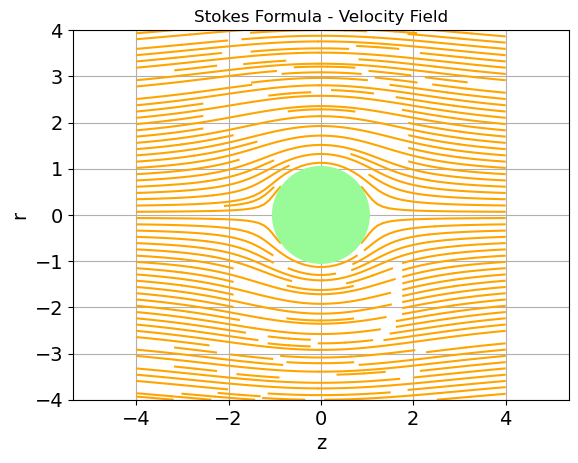

In [4]:
plt.figure()

ystart = np.array([-0.2,-0.35,-0.5,-0.75,-1,-1.25,-1.5,-1.75,-2,-2.5,-3,-3.5,-4])
zstart = -4*np.ones_like(ystart)

plt.streamplot(z,y,vz,vy,color='orange',density=2, arrowstyle='-')

ystart = (-1)*np.array([-0.2,-0.35,-0.5,-0.75,-1,-1.25,-1.5,-1.75,-2,-2.5,-3,-3.5,-4])

#quiver(z,y,vz,vy,color=...)

plt.axis('equal')
plt.xlabel('z',fontsize=14)
plt.ylabel('r',fontsize=14)

str_title = "Stokes Formula - Velocity Field"
h = plt.title(str_title)

PlotCircle(0,0,1,"palegreen",4)

plt.axis([-4,4,-4,4])
plt.grid(True)
plt.gca().tick_params(labelsize=14)
plt.show()

## Visualization - Pressure Calculation

In [5]:
eta = 1
p = -3000/2 * eta * v0 * r0 * z / r**3

## Pressure Contour Plot

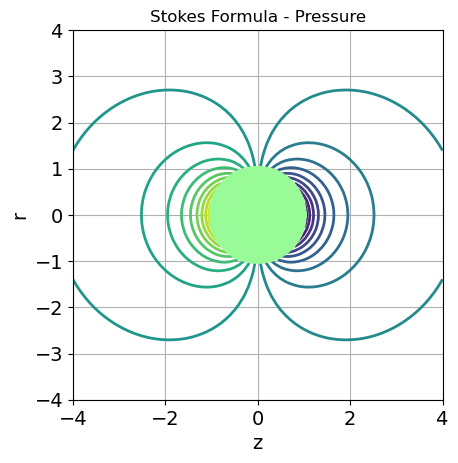

In [6]:
plt.figure()

levels = np.linspace(np.nanmin(p),np.nanmax(p),20)
plt.contour(z,y,p,levels,linewidths=2)

str_title = "Stokes Formula - Pressure"
h2 = plt.title(str_title)

PlotCircle(0,0,1,'palegreen',4)

plt.axis([-4,4,-4,4])
plt.xlabel('z',fontsize=14)
plt.ylabel('r',fontsize=14)


plt.gca().set_aspect('equal', adjustable='box')
plt.xlim(-4,4)
plt.ylim(-4,4)

plt.grid(True)
plt.gca().tick_params(labelsize=14)
plt.show()